# Dengue Fever AI - Predicting Disease Spread

In [148]:
%matplotlib inline
import pickle
import numpy as np
import pandas as pd

# Visualization tool
from matplotlib import pyplot as pl
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

import pickle

from warnings import filterwarnings
filterwarnings("ignore")

print("---------\nDone")

---------
Done


## Data Prep

In [79]:
def wrangle(filepath, labels_path=None):
    df = pd.read_csv(filepath, index_col=[0,1,2])

    df.fillna(method="ffill", inplace=True)

    if labels_path:
        label = pd.read_csv(labels_path, index_col=[0,1,2])
        df = df.join(label)

        df.drop("week_start_date", axis=1, inplace=True)

    return df

In [80]:
# load the data
train_df = wrangle("./data/dengue_features_train.csv", "./data/dengue_labels_train.csv")
train_df.head()

ndvi_ne   ndvi_nw   ndvi_se   ndvi_sw  \
city year weekofyear                                           
sj   1990 18          0.122600  0.103725  0.198483  0.177617   
          19          0.169900  0.142175  0.162357  0.155486   
          20          0.032250  0.172967  0.157200  0.170843   
          21          0.128633  0.245067  0.227557  0.235886   
          22          0.196200  0.262200  0.251200  0.247340   

                      precipitation_amt_mm  reanalysis_air_temp_k  \
city year weekofyear                                                
sj   1990 18                         12.42             297.572857   
          19                         22.82             298.211429   
          20                         34.54             298.781429   
          21                         15.36             298.987143   
          22                          7.52             299.518571   

                      reanalysis_avg_temp_k  reanalysis_dew_point_temp_k  \
city year weekofyear                                                       
sj   1990 18                     297.742857                   292.414286   
          19                     298.442857                   293.951429   
          20                     298.878571                   295.434286   
          21                     299.228571                   295.310000   
          22                     299.664286                   295.821429   

                      reanalysis_max_air_temp_k  reanalysis_min_air_temp_k  \
city year weekofyear                                                         
sj   1990 18                              299.8                      295.9   
          19                              300.9                      296.4   
          20                              300.5                      297.3   
          21                              301.4                      297.0   
          22                              301.9                      297.5   

                      ...  reanalysis_relative_humidity_percent  \
city year weekofyear  ...                                         
sj   1990 18          ...                             73.365714   
          19          ...                             77.368571   
          20          ...                             82.052857   
          21          ...                             80.337143   
          22          ...                             80.460000   

                      reanalysis_sat_precip_amt_mm  \
city year weekofyear                                 
sj   1990 18                                 12.42   
          19                                 22.82   
          20                                 34.54   
          21                                 15.36   
          22                                  7.52   

                      reanalysis_specific_humidity_g_per_kg  \
city year weekofyear                                          
sj   1990 18                                      14.012857   
          19                                      15.372857   
          20                                      16.848571   
          21                                      16.672857   
          22                                      17.210000   

                      reanalysis_tdtr_k  station_avg_temp_c  \
city year weekofyear                                          
sj   1990 18                   2.628571           25.442857   
          19                   2.371429           26.714286   
          20                   2.300000           26.714286   
          21                   2.428571           27.471429   
          22                   3.014286           28.942857   

                      station_diur_temp_rng_c  station_max_temp_c  \
city year weekofyear                                                
sj   1990 18                         6.900000                29.4   
          19                         6.371429                31.7   
 

In [101]:
print(f"Shape: {train_df.shape}")

Shape: (1456, 21)


In [81]:
# Compute the correlations
df_correlations = train_df.corr()

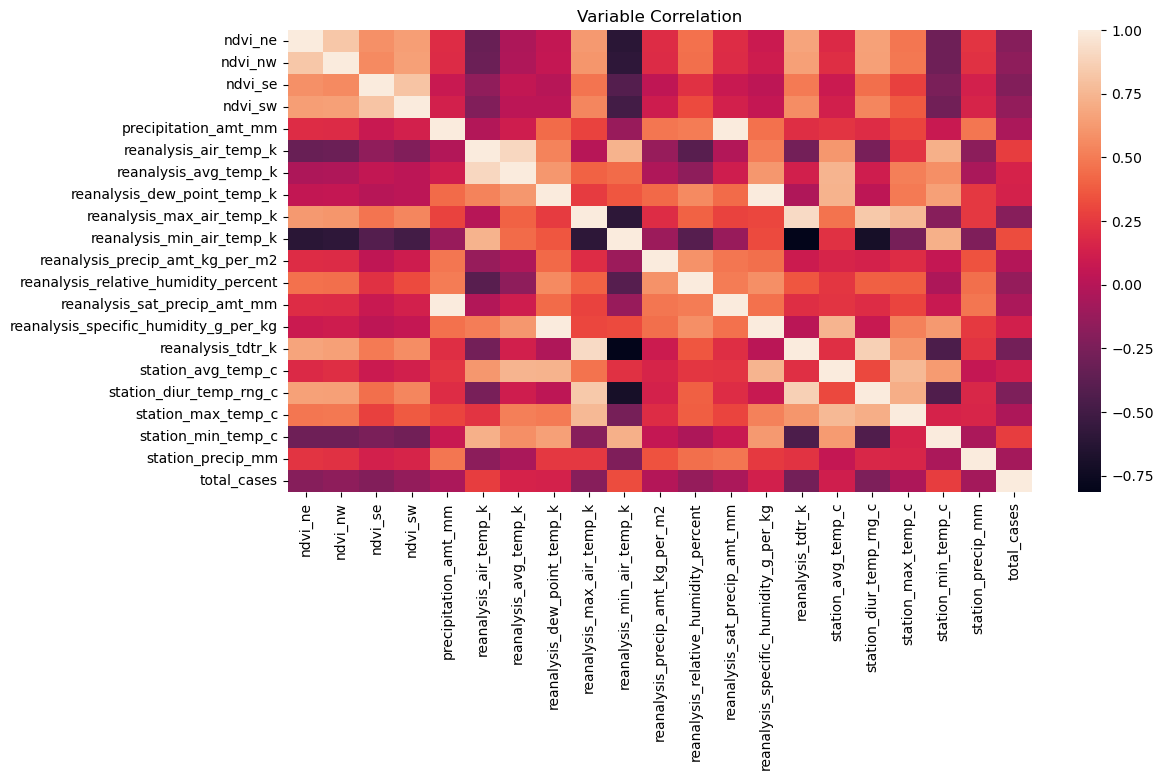

In [82]:
# Plot Correlation features
plt.figure(figsize=[12, 6])
df_corr_heat = sns.heatmap(df_correlations)
plt.title("Variable Correlation");

<Axes: >

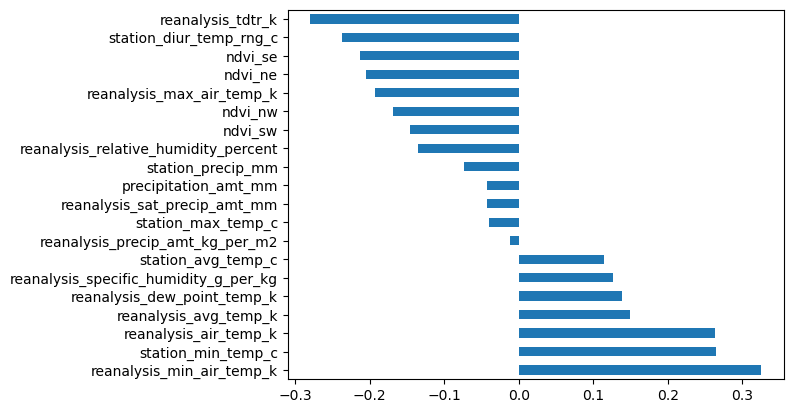

In [83]:
# San Juan
(df_correlations
     .total_cases
     .drop('total_cases') # don't compare with myself
     .sort_values(ascending=False)
     .plot
     .barh())

### Split Data

In [104]:

features = train_df[["reanalysis_min_air_temp_k", "reanalysis_air_temp_k", "station_min_temp_c", "reanalysis_avg_temp_k",
        "reanalysis_dew_point_temp_k", "reanalysis_precip_amt_kg_per_m2", "reanalysis_specific_humidity_g_per_kg",
        "station_avg_temp_c"]]

target = "total_cases"

X = features
y = train_df[target]

In [105]:
# Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [106]:
print(f"X_train shape: {X_train.shape}\ny_train shape: {y_train.shape}\nX_val Shape: {X_val.shape}\ny_val shape: {y_val.shape}")

X_train shape: (1164, 8)
y_train shape: (1164,)
X_val Shape: (292, 8)
y_val shape: (292,)


In [110]:
round(X_val.shape[0] * 100 / len(train_df), 0)

20.0

In [112]:
round(X_train.shape[0] * 100 / len(train_df), 0)

80.0

## Build Model

### Baseline

In [122]:
y_pred_baseline = [y_train.mean()] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print("Mean:", round(y_train.mean(), 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean: 23.12
Baseline MAE: 20.99


### Iterate

In [125]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [126]:
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)

mae_train = mean_absolute_error(y_train, train_pred)
mae_val = mean_absolute_error(y_val, val_pred)

In [127]:
print(f"Training MAE: {round(mae_train, 2)}")
print(F"Validation MAE: {round(mae_val)}")

Training MAE: 18.79
Validation MAE: 25


In [128]:
intercept = model.intercept_.round(2)
coefficient = model.coef_.round(2)

In [130]:
test_df = wrangle("./data/dengue_features_train.csv")
test_df.drop("week_start_date", axis=1, inplace=True)
test_df.head()

ndvi_ne   ndvi_nw   ndvi_se   ndvi_sw  \
city year weekofyear                                           
sj   1990 18          0.122600  0.103725  0.198483  0.177617   
          19          0.169900  0.142175  0.162357  0.155486   
          20          0.032250  0.172967  0.157200  0.170843   
          21          0.128633  0.245067  0.227557  0.235886   
          22          0.196200  0.262200  0.251200  0.247340   

                      precipitation_amt_mm  reanalysis_air_temp_k  \
city year weekofyear                                                
sj   1990 18                         12.42             297.572857   
          19                         22.82             298.211429   
          20                         34.54             298.781429   
          21                         15.36             298.987143   
          22                          7.52             299.518571   

                      reanalysis_avg_temp_k  reanalysis_dew_point_temp_k  \
city year weekofyear                                                       
sj   1990 18                     297.742857                   292.414286   
          19                     298.442857                   293.951429   
          20                     298.878571                   295.434286   
          21                     299.228571                   295.310000   
          22                     299.664286                   295.821429   

                      reanalysis_max_air_temp_k  reanalysis_min_air_temp_k  \
city year weekofyear                                                         
sj   1990 18                              299.8                      295.9   
          19                              300.9                      296.4   
          20                              300.5                      297.3   
          21                              301.4                      297.0   
          22                              301.9                      297.5   

                      reanalysis_precip_amt_kg_per_m2  \
city year weekofyear                                    
sj   1990 18                                    32.00   
          19                                    17.94   
          20                                    26.10   
          21                                    13.90   
          22                                    12.20   

                      reanalysis_relative_humidity_percent  \
city year weekofyear                                         
sj   1990 18                                     73.365714   
          19                                     77.368571   
          20                                     82.052857   
          21                                     80.337143   
          22                                     80.460000   

                      reanalysis_sat_precip_amt_mm  \
city year weekofyear                                 
sj   1990 18                                 12.42   
          19                                 22.82   
          20                                 34.54   
          21                                 15.36   
          22                                  7.52   

                      reanalysis_specific_humidity_g_per_kg  \
city year weekofyear                                          
sj   1990 18                                      14.012857   
          19                                      15.372857   
          20                                      16.848571   
          21                                      16.672857   
          22                                      17.210000   

                      reanalysis_tdtr_k  station_avg_temp_c  \
city year weekofyear                                          
sj   1990 18                   2.628571           25.442857   
          19                   2.371429           26.714286   
          20                   2.300000           26.714286   
          21                   2.428571

In [134]:
print(f"Intercept: {intercept:.2f}")
print(f"Coefficients: {coefficient}")

Intercept: 2661.18
Coefficients: [  2.29  15.79  -0.3  -15.59 -12.38   0.03  12.74   2.97]


In [137]:
test_df = test_df[["reanalysis_min_air_temp_k", "reanalysis_air_temp_k", "station_min_temp_c", "reanalysis_avg_temp_k",
        "reanalysis_dew_point_temp_k", "reanalysis_precip_amt_kg_per_m2", "reanalysis_specific_humidity_g_per_kg",
        "station_avg_temp_c"]]

In [138]:
test_pred = model.predict(test_df)
test_pred

array([24.37698068, 25.62870626, 30.43209223, ...,  1.03355352,
       -0.33213537, -2.09232353], shape=(1456,))

In [140]:
predictions = np.round(test_pred).astype(int)

In [141]:
# Reset the multiple index column
submission_df = test_df.reset_index()

In [142]:
# Add total cases to the prediction
submission_df["total_cases"] = predictions

# Select to reorder colums
submission_df = submission_df[['city', 'year', 'weekofyear', 'total_cases']]
print(submission_df)

     city  year  weekofyear  total_cases
0      sj  1990          18           24
1      sj  1990          19           26
2      sj  1990          20           30
3      sj  1990          21           29
4      sj  1990          22           36
...   ...   ...         ...          ...
1451   iq  2010          21           13
1452   iq  2010          22           14
1453   iq  2010          23            1
1454   iq  2010          24            0
1455   iq  2010          25           -2

[1456 rows x 4 columns]


In [146]:
# Save the sumbitted predictions to csv
submission_df.to_csv("./data/submit.csv", index=False)

In [147]:
# test the submited data
sd = pd.read_csv("./data/submit.csv")
sd.head()

,city,year,weekofyear,total_cases
0,sj,1990,18,24
1,sj,1990,19,26
2,sj,1990,20,30
3,sj,1990,21,29
4,sj,1990,22,36


In [149]:
with open("model_lr.pkl", "wb") as f:
    pickle.dump(model, f)

In [167]:
sd.drop(columns=["id"], inplace=True)
sd.head()

,city,year,weekofyear,total_cases
0,sj,1990,18,24
1,sj,1990,19,26
2,sj,1990,20,30
3,sj,1990,21,29
4,sj,1990,22,36


In [168]:
sd.set_index(["city", "year", "weekofyear"])
sd.head()

,city,year,weekofyear,total_cases
0,sj,1990,18,24
1,sj,1990,19,26
2,sj,1990,20,30
3,sj,1990,21,29
4,sj,1990,22,36


In [172]:
sd.to_csv("./data/submit.csv", index=False)
s = pd.read_csv("./data/submit.csv")
s.head()

,city,year,weekofyear,total_cases
0,sj,1990,18,24
1,sj,1990,19,26
2,sj,1990,20,30
3,sj,1990,21,29
4,sj,1990,22,36
